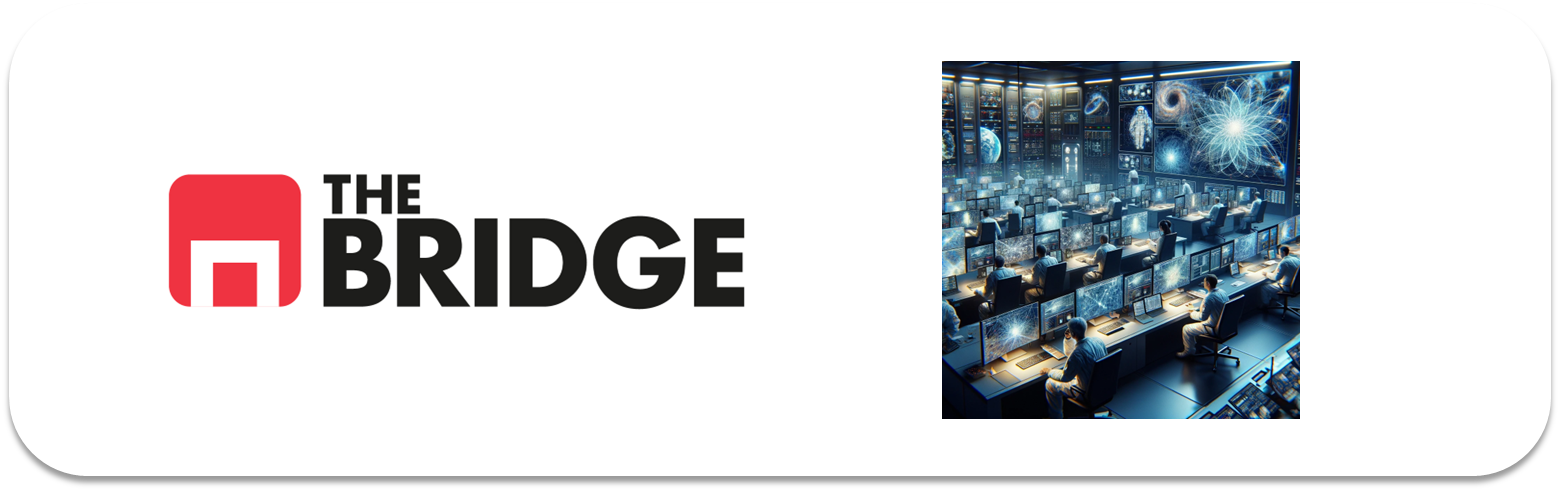

## PRACTICA OBLIGATORIA: **Transfer Learning y Fine Tuning con CNN**

* La práctica obligatoria de esta unidad consiste en un repetir el ejercicio de construcción de un modelo de clasificación de paisajes pero usando un modelo preentrenado. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

### Objetivo del ejercicio

Comparar una red convolucional hecha ad-hoc frente a los modelos preentrenados y ajustados con fine tuning y transfer learning. Para ello emplea el dataset de paisajes del conjunto de ejercicios de la unidad anterior.


### Se pide

1. Preparar los datos del modelo y las funciones de visualización, copia para ello todo lo que necesites de las soluciones del ejercicio de clasificación de paisajes de la unidad anterior.

2. Escoger entre uno de los modelos VGG-19, InceptionV3 y MobileNetV2 (todos en https://keras.io/api/applications/) (Se aconseja este último si no tenemos un ordenador muy potente). Si no te haces con estos puedes recurrir a la ResNetV50.

4. Hacer un transfer-learning con una cabeza de como mucho 2 capas densas ocultas y una de salida. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

5. Hacer un fine-tuning con la misma cabeza diseñada en el punto anterior. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

6. Comparar los resultados con los obtenidos con la red convolucional del ejercicio mencionado.

EXTRA:
- Repetir el transfer learning empleando aumentado de imágenes.



In [1]:
import cv2
import keras
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns

from skimage.io import imread
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from time import time
import gc

In [2]:
import kagglehub

path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files: ", path)

C:\Users\m_fon\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files:  C:\Users\m_fon\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2


In [3]:
ROOT_PATH = path

In [4]:
os.listdir(path)

['seg_pred', 'seg_test', 'seg_train']

In [5]:
os.listdir(path + "/seg_train/seg_train")

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

creamos los paths a los diferentes datasets

In [6]:
TRAIN_PATH = ROOT_PATH + "/seg_train/seg_train"
TEST_PATH = ROOT_PATH + "/seg_test/seg_test"

In [7]:
os.listdir(TRAIN_PATH)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

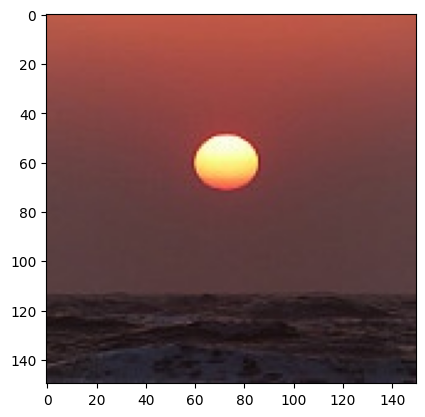

In [8]:
plt.imshow(imread(TRAIN_PATH + "/sea/" + "/11321.jpg"))
plt.show()

In [9]:
imread(TRAIN_PATH + "/sea/" + "/11321.jpg").shape
# 150 px de ancho de alto y tres canales de color

(150, 150, 3)

In [10]:
IMG_WIDTH = IMG_HEIGHT = 75
# ej la docu de inceptionv3 el shape del input no puede ser menor de 75

In [11]:
def read_data(directorio, reshape_dim = (IMG_WIDTH, IMG_HEIGHT)):
    x =  []
    y =  []
    for folder in os.listdir(directorio):
        print(folder)
        if os.path.isdir('/'.join([directorio, folder])):
            for file in os.listdir('/'.join([directorio, folder])):
                
                image = imread('/'.join([directorio, folder, file]))
                image = cv2.resize(image, reshape_dim) # se redimesniona a 75 x 75
                
                x.append(image)
                y.append(folder)
                
    return np.array(x), np.array(y)

def show_images_batch(paisajes, names = [], n_cols = 5, size_scale = 2):
    
    n_rows = ((len(paisajes) -1) // n_cols +1)
    plt.figure(figsize = (n_cols*size_scale, n_rows * 1.1 * size_scale))
    for index, paisaje in enumerate(paisajes):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(paisaje, cmap = "Greys")
        plt.axis("off")
        if len(names):
            plt.title(names[index])

In [12]:
X_train, y_train = read_data(TRAIN_PATH)
X_test, y_test = read_data(TEST_PATH)

buildings
forest
glacier
mountain
sea
street
buildings
forest
glacier
mountain
sea
street


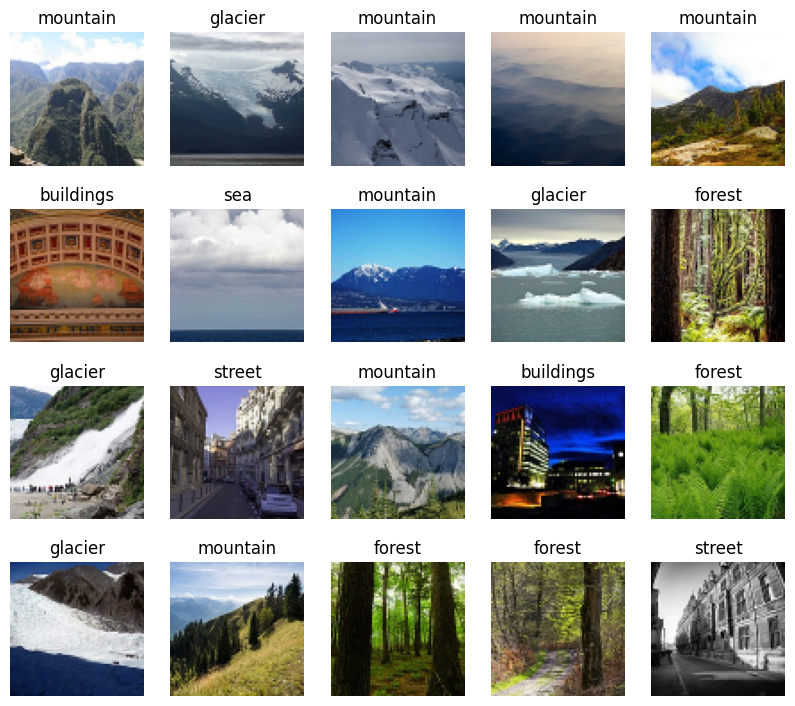

In [13]:
indices = np.random.randint(0, len(X_train), 20)
show_images_batch(X_train[indices], names = y_train[indices], n_cols=5)

In [14]:
X_train.shape

(14034, 75, 75, 3)

In [15]:
X_train.size
# total de parámetros 14034x75x75x3

236823750

In [16]:
pd.Series(y_train).value_counts(True)*100
# target balanceado

mountain     17.899387
glacier      17.129828
street       16.973065
sea          16.203506
forest       16.182129
buildings    15.612085
Name: proportion, dtype: float64

In [17]:
# el escalado de inception v3 es entre 1 y -1 (ver documentación)
X_train = (X_train/127.5) - 1
X_test = (X_test/127.5) - 1

In [18]:
from keras.applications import InceptionV3

In [19]:
# creamos un modelo temproal
temp_model = InceptionV3(include_top=False, weights='imagenet', input_shape=(75, 75, 3))
# include_top es el final del propio modelo

In [20]:
temp_model.input

<KerasTensor shape=(None, 75, 75, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor>

In [21]:
temp_model.output
# 2048 columnas sería la parte flatten

<KerasTensor shape=(None, 1, 1, 2048), dtype=float32, sparse=False, ragged=False, name=keras_tensor_310>

In [22]:
del temp_model
gc.collect

<function gc.collect(generation=2)>

In [23]:
# construcción del modelo completo
IMG_HEIGHT = IMG_WIDTH = 75

base_model = InceptionV3(include_top=False, weights='imagenet', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# por cada capa se hace que cada una use la mayoría de pesos correctos de iamgenet
for layer in base_model.layers:
    layer.trainable = False
    
def prepare_model(base_model = base_model):
    x = keras.layers.Flatten()(base_model.output) # quero que coja la salida el mismo numero de neuronas
    x = keras.layers.Dense(2048, activation='relu')(x) # la dense va a ser la entrada
    x = keras.layers.Dropout(rate = 0.25)(x)
    
    modelo = keras.layers.Dense(6, activation='softmax')(x)
    
    modelo = keras.Model(base_model.input, x)
    
    modelo.compile(
        optimizer = "adam", 
        loss = "sparse_categorical_crossentropy",
        metrics= ["acc"]
    )
    
    return modelo

model = prepare_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 75, 75, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_94 (Conv2D)  │ (None, 37, 37,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 37, 37,    │         96 │ conv2d_94[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_94       │ (None, 37, 37,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, 35, 35,    │      9,216 │ activation_94[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │         96 │ conv2d_95[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_95       │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, 35, 35,    │     18,432 │ activation_95[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │        192 │ conv2d_96[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_96       │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 17, 17,    │          0 │ activation_96[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_97 (Conv2D)  │ (None, 17, 17,    │      5,120 │ max_pooling2d_4[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 17, 17,    │        240 │ conv2d_97[0][0]   │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_97       │ (None, 17, 17,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_98 (Conv2D)  │ (None, 15, 15,    │    138,240 │ activation_97[0]… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 15,    │        576 │ conv2d_98[0][0]   │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_98       │ (None, 15, 15,    │          0 │ batch_normalizat

 Total params: 25,999,136 (99.18 MB)

 Trainable params: 4,196,352 (16.01 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [24]:
# configuración de hiperparámetros
X_train.shape[0]*.8

# 80% del primer elemnto

11227.2

In [25]:
# número de instancias de train 
instancias_train = len(X_train)
# tamaño de los batchs
for i in range(1,5):
    print(f"Batch_size: {32*i}, num_step_per_epoch:{round((instancias_train*.8)/(32*i))}")

Batch_size: 32, num_step_per_epoch:351
Batch_size: 64, num_step_per_epoch:175
Batch_size: 96, num_step_per_epoch:117
Batch_size: 128, num_step_per_epoch:88


In [26]:
y_train
# transformarmos las palabras

array(['buildings', 'buildings', 'buildings', ..., 'street', 'street',
       'street'], shape=(14034,), dtype='<U9')

In [27]:
targets = pd.Series(y_train)
# mapeamos
mapa = {tipo: indice for indice, tipo in enumerate(targets.unique())}
mapa

{'buildings': 0,
 'forest': 1,
 'glacier': 2,
 'mountain': 3,
 'sea': 4,
 'street': 5}

In [28]:
y_train_num = np.array([mapa[y] for y in y_train])
y_test_num = np.array([mapa[y] for y in y_test])

In [29]:
BATCH_SIZE = 128
earlyS = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)

In [30]:
# hacemos shuffle
X_train_s, y_train_s = shuffle(X_train, y_train_num)

In [31]:
t_zero = time()

model = prepare_model()
history = model.fit(X_train_s,
                    y_train_s, 
                    batch_size=BATCH_SIZE,
                    validation_split=.2,
                    epochs = 40,
                    callbacks = earlyS)

tiempo = round(time() - t_zero, 3)

Epoch 1/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 35s 325ms/step - acc: 0.1995 - loss: 5.6263 - val_acc: 0.2081 - val_loss: 1.7573
Epoch 2/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 28s 319ms/step - acc: 0.2020 - loss: 5.4282 - val_acc: 0.2323 - val_loss: 1.6539
Epoch 3/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 26s 299ms/step - acc: 0.2295 - loss: 5.4322 - val_acc: 0.2091 - val_loss: 1.8322
Epoch 4/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 29s 324ms/step - acc: 0.2433 - loss: 5.1724 - val_acc: 0.2700 - val_loss: 1.7308
Epoch 5/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 27s 306ms/step - acc: 0.2803 - loss: 5.1221 - val_acc: 0.3441 - val_loss: 1.5693
Epoch 6/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 26s 295ms/step - acc: 0.3251 - loss: 5.2333 - val_acc: 0.3637 - val_loss: 3.7515
Epoch 7/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 28s 317ms/step - acc: 0.3767 - loss: 5.9611 - val_acc: 0.3281 - val_loss: 6.2481
Epoch 8/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 28s 314ms/step - acc: 0.2762 - loss: 6.7558 - val_acc: 0.3021 - val_loss: 6.4522
Epoch 9/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 26s 297ms/

In [32]:
print(tiempo)

420.292


In [33]:
model.evaluate(X_test, y_test_num)

94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - acc: 0.3557 - loss: 1.5888


[1.5887541770935059, 0.3556666672229767]

In [34]:
y_pred = [np.argmax(prediction) for prediction in model.predict(X_test)]

94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step


In [35]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# volvermos del número a la palabra invertimos el mapeo
inverse_map = {valor: clave for clave, valor in mapa.items()}

y_test_label = [inverse_map[y] for y in y_test_num]
y_pred_label = [inverse_map[y] for y in y_pred]

In [36]:
print(classification_report(y_test_label, y_pred_label))
# el peor uele ser las calsificaciones de montaña

              precision    recall  f1-score   support

   buildings       0.88      0.19      0.32       437
      forest       0.96      0.59      0.73       474
     glacier       0.23      0.75      0.35       553
    mountain       0.19      0.22      0.20       525
         sea       0.75      0.28      0.41       510
      street       0.83      0.07      0.13       501

    accuracy                           0.36      3000
   macro avg       0.64      0.35      0.36      3000
weighted avg       0.62      0.36      0.35      3000



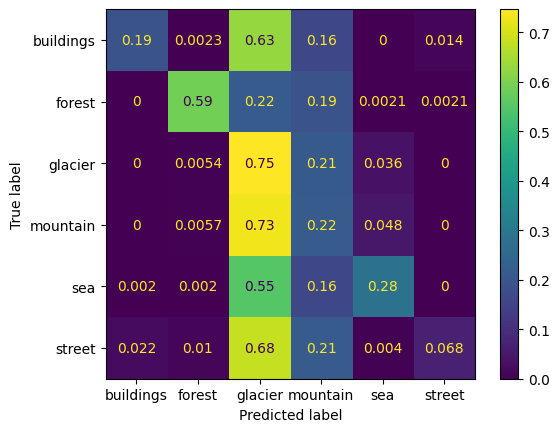

In [37]:
ConfusionMatrixDisplay.from_predictions(y_test_label, y_pred_label, normalize = "true")

plt.show()

# los gglacaiares y montañas se confunden mucho y street con edificios algo mneos
# demomento hay un 79n de precision

In [38]:
del model
del history
gc.collect()

# importante para liberar memoria

7524

FINE TUNNING

In [ ]:
# construcción del modelo completo
IMG_HEIGHT = IMG_WIDTH = 75

base_model = InceptionV3(include_top=False, weights='imagenet', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# por cada capa se hace que cada una use la mayoría de pesos correctos de iamgenet
#for layer in base_model.layers:
#   layer.trainable = False
    
def prepare_model(base_model = base_model):
    x = keras.layers.Flatten()(base_model.output) # quero que coja la salida el mismo numero de neuronas
    x = keras.layers.Dense(2048, activation='relu')(x) # la dense va a ser la entrada
    x = keras.layers.Dropout(rate = 0.25)(x)
    
    modelo = keras.layers.Dense(6, activation='softmax')(x)
    
    modelo = keras.Model(base_model.input, x)
    
    modelo.compile(
        optimizer = "adam", 
        loss = "sparse_categorical_crossentropy",
        metrics= ["acc"]
    )
    
    return modelo

model = prepare_model()
model.summary()